In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import skill_metrics as sm
import warnings
from glob import glob
from scipy.stats import wasserstein_distance

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.mpl.geoaxes as cgeo

warnings.filterwarnings("ignore")

In [2]:
# Constants

START_DATE = np.datetime64('2000-01-01T00:00:00.000000000')
END_DATE = np.datetime64('2023-09-30T23:00:00.000000000')
# START_DATE = np.datetime64('2000-01-01T00:00:00.000000000')
# END_DATE = np.datetime64('2010-12-31T23:00:00.000000000')
N_HOURS = (END_DATE - START_DATE) / np.timedelta64(1, 'h') + 1
N_DAYS = np.round((END_DATE - START_DATE) / np.timedelta64(1, 'D'))
print(N_HOURS, N_DAYS)

COVERAGE_THRESHOLD = 0.9
ZSCORE_THRESHOLD = 5  # for outlier detection; may want to adjust (this seems to reject some plausible Wind Spd values, for instance)
vars = [
    "Wind Spd (km/h)",
]

BAD_MONTHS = [[2005, 4],
             [2005, 7],
             [2005, 10],
             [2006, 3],
             [2006, 9],
             [2008, 7],
             [2015, 10],
             [2017, 8],
             [2017, 11],
             [2019, 9],
             [2021, 7],
             [2022, 2],
             [2023, 6]]

full_time_index = pd.Index(
    np.arange(START_DATE, END_DATE + np.timedelta64(1, 'h'), np.timedelta64(1, 'h')),
    name='Date/Time (LST)'
    )

208176.0 8674.0


In [3]:
def readable_time_coord(ds, time_var='Times'):

    time_vals = ds[time_var].values

    # Extract integer (YYYYMMDD) and fractional day parts
    dates_int = time_vals.astype(int)
    frac_days = time_vals - dates_int

    # Parse integers to datetime
    base_dates = pd.to_datetime(dates_int.astype(str), format="%Y%m%d")

    # Add fractional day as timedelta
    full_times = base_dates + pd.to_timedelta(frac_days, unit="D")
    full_times = full_times.round("1h")

    # Assign back to dataset
    ds = ds.assign_coords({time_var: full_times})
    ds = ds.transpose(time_var, ...)

    ds = ds.rename({time_var: "time"})
    
    return ds

# Find the nearest grid point in winds_ds to the station's lat/lon
def get_nearest_wrf_point(ds, lat, lon):
    abs_lat = np.abs(ds['XLAT'] - lat)
    abs_lon = np.abs(ds['XLONG'] - lon)
    dist = abs_lat + abs_lon
    # Find indices of the minimum distance
    idx = np.unravel_index(np.argmin(dist.values), dist.shape)
    return idx

# Open WRF Data

In [4]:
wrf_static = xr.open_mfdataset("/users/rpayne/data/unproc/WRF-UBC/ubc_wrf_staticfields_d03.nc")
hgt = wrf_static['HGT'].values.squeeze()
landmask = wrf_static['LANDMASK'].values.squeeze()

# DAILY MEAN humid

humid_ds = readable_time_coord(xr.open_dataset("/users/rpayne/data/unproc/WRF-UBC/Q2/Q2_dailymean_199910_202309.nc"))
humid_ds = humid_ds.sel(time=slice(START_DATE, END_DATE)).drop_vars('Times_bnds')

humid_ds

<xarray.Dataset> Size: 13GB
Dimensions:  (south_north: 702, west_east: 558, time: 8566)
Coordinates:
    XLONG    (south_north, west_east) float32 2MB ...
    XLAT     (south_north, west_east) float32 2MB ...
  * time     (time) datetime64[ns] 69kB 2000-01-01T12:00:00 ... 2023-09-30T12...
Dimensions without coordinates: south_north, west_east
Data variables:
    Q2       (time, south_north, west_east) float32 13GB ...
Attributes: (12/91)
    CDI:                             Climate Data Interface version 1.9.9rc1 ...
    Conventions:                     CF-1.6
    history:                         Thu Aug 14 13:42:39 2025: cdo daymean -s...
    TITLE:                            OUTPUT FROM WRF V4.4.2 MODEL
    START_DATE:                      1999-10-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        559
    ...                              ...
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2
    frequency:                       day
    CDO:                             Climate Data Operators version 1.9.9rc1 ...

# Open STN Data

In [5]:
# Takes ~5 minutes to run

wx_data_fnames = sorted(glob("/users/rpayne/data/unproc/STN_ECCC/api/hourly/*.csv"))
df = pd.concat(
    (pd.read_csv(f, encoding='latin1', low_memory=False) for f in wx_data_fnames),
    ignore_index=True
)
df['Date/Time (LST)'] = pd.to_datetime(df['Date/Time (LST)'], format='%Y-%m-%d %H:%M:%S')
df = df[df['Date/Time (LST)'] >= START_DATE]  # Filter for data to align w WRF
df = df[df['Date/Time (LST)'] <= END_DATE]
df.set_index('Date/Time (LST)', inplace=True)
df.rename(columns={"Temp (Â°C)": "Temp (°C)"}, inplace=True)
df.rename(columns={"Dew Point Temp (Â°C)": "Dew Point Temp (°C)"}, inplace=True)
df

,Longitude (x),Latitude (y),Station Name,Climate ID,Year,Month,Day,Time (LST),Flag,Temp (°C),...,Visibility Flag,Stn Press (kPa),Stn Press Flag,Hmdx,Hmdx Flag,Wind Chill,Wind Chill Flag,Weather,Precip. Amount (mm),Precip. Amount Flag
Date/Time (LST),,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,00:00,NaN,-0.4,...,M,NaN,M,NaN,NaN,-4.0,NaN,NaN,NaN,NaN
2000-01-01 01:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,01:00,NaN,-0.2,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
2000-01-01 02:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,02:00,NaN,-0.2,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
2000-01-01 03:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,03:00,NaN,-0.2,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
2000-01-01 04:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,04:00,NaN,-0.5,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-30 19:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2023,9,30,19:00,NaN,11.9,...,NaN,96.51,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2023-09-30 20:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2023,9,30,20:00,NaN,11.4,...,NaN,96.55,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2023-09-30 21:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2023,9,30,21:00,NaN,10.8,...,NaN,96.59,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


In [6]:
# Create a dictionary mapping station name to (lat, lon) from df
stn_latlon = {}
stns = df["Station Name"].unique()
for stn in stns:
    stn_rows = df[df["Station Name"] == stn]
    if not stn_rows.empty:
        lat = stn_rows["Latitude (y)"].iloc[0]
        lon = stn_rows["Longitude (x)"].iloc[0]
        stn_latlon[stn] = (lat, lon)
    else:
        stn_latlon[stn] = (None, None)


def get_stn(stn_name, data=df):
    stn = data[data["Station Name"] == stn_name]
    stn = stn.sort_index()
    stn = stn[~stn.index.duplicated(keep='last')]
    stn = stn.reindex(full_time_index)
    return stn

In [7]:
m_v = 18.01528e-3 # kg/mol
m_d = 28.9647e-3 # kg/mol
e0 = 0.611 # kPa
T0 = 273.15 # K
L_v = 2.45e6 # J/kg
R = 8.314 # J/(mol*K)

df["Specific Humidity (kg/kg)"] = np.exp((m_v * L_v / R) * (1/T0 - 1/(df["Dew Point Temp (°C)"] + 273.15))) * (m_v/m_d) * (e0 / df["Stn Press (kPa)"])

In [8]:
# Find all stations that meet the coverage threshold for the given variables

Q2_coverage_dict = {}

for i,stn in enumerate(stns):
    print(f"{i+1}/{len(stns)}")
    
    stn_data = get_stn(stn)

    Q2_data = stn_data["Specific Humidity (kg/kg)"].resample('D').mean()
    Q2_coverage = np.count_nonzero(~np.isnan(Q2_data)) / N_DAYS
    if Q2_coverage >= COVERAGE_THRESHOLD:
        Q2_coverage_dict[stn] = Q2_coverage

Q2_stns = np.sort(list(Q2_coverage_dict.keys()))

print(f"Number of stations with adequate Q2 coverage: {len(Q2_stns)}")

1/203
2/203
3/203
4/203
5/203
6/203
7/203
8/203
9/203
10/203
11/203
12/203
13/203
14/203
15/203
16/203
17/203
18/203
19/203
20/203
21/203
22/203
23/203
24/203
25/203
26/203
27/203
28/203
29/203
30/203
31/203
32/203
33/203
34/203
35/203
36/203
37/203
38/203
39/203
40/203
41/203
42/203
43/203
44/203
45/203
46/203
47/203
48/203
49/203
50/203
51/203
52/203
53/203
54/203
55/203
56/203
57/203
58/203
59/203
60/203
61/203
62/203
63/203
64/203
65/203
66/203
67/203
68/203
69/203
70/203
71/203
72/203
73/203
74/203
75/203
76/203
77/203
78/203
79/203
80/203
81/203
82/203
83/203
84/203
85/203
86/203
87/203
88/203
89/203
90/203
91/203
92/203
93/203
94/203
95/203
96/203
97/203
98/203
99/203
100/203
101/203
102/203
103/203
104/203
105/203
106/203
107/203
108/203
109/203
110/203
111/203
112/203
113/203
114/203
115/203
116/203
117/203
118/203
119/203
120/203
121/203
122/203
123/203
124/203
125/203
126/203
127/203
128/203
129/203
130/203
131/203
132/203
133/203
134/203
135/203
136/203
137/203
138/203
139/

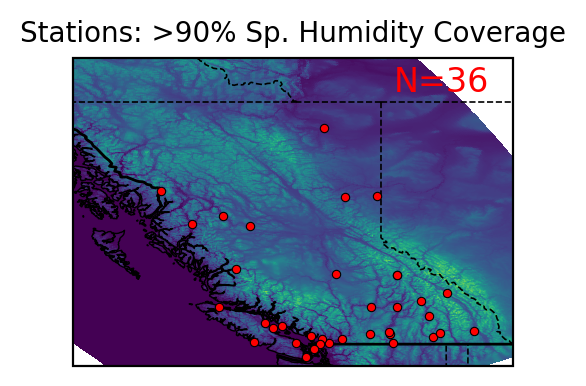

In [9]:
lon = wrf_static['XLONG'].values.squeeze()
lat = wrf_static['XLAT'].values.squeeze()

# Create a figure
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()},figsize=(4,2),dpi=200)

# Plot using pcolormesh
mesh = ax.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto')
ax.coastlines(linewidth=0.5,zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=1)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=1)
ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=1)
for stn in Q2_coverage_dict.keys():
    lat, lon = stn_latlon[stn]
    ax.scatter(lon, lat, marker='.', facecolor='red', edgecolor='k', linewidth=.4, transform=ccrs.PlateCarree())
ax.set_xlim(-134, -114)
ax.set_ylim(48, 62)
ax.text(-119.4, 60.5, f"N={len(Q2_coverage_dict.keys())}", fontsize=12, transform=ccrs.PlateCarree(), color='red')

ax.set_title(f"Stations: >{100*COVERAGE_THRESHOLD:.0f}% Sp. Humidity Coverage", fontsize=10)
plt.show()

# Analysis

In [10]:
# Create an index for the pd dataframe that ranges over the entire period
# by START_DATE and END_DATE:

full_time_index = pd.Index(
    np.arange(START_DATE, END_DATE + np.timedelta64(1, 'h'), np.timedelta64(1, 'h')),
    name='Date/Time (LST)'
    )

def sort_data(data, lats, lons):
    sorted_indices = np.argsort(data)
    lons = [lons[i] for i in sorted_indices]
    lats = [lats[i] for i in sorted_indices]
    data = [data[i] for i in sorted_indices]
    return data, lats, lons

In [11]:
wass_dict = {}
corr_dict = {}
rmse_dict = {}
urmse_dict = {}
bmean_dict = {}
bmedian_dict = {}
b95p_dict = {}

for i, stn in enumerate(Q2_coverage_dict.keys()):

    # Get station data
    print(f"({i+1}/{len(Q2_coverage_dict)}) Working on {stn}...")

    data = get_stn(stn)
    lat = stn_latlon[stn][0]
    lon = stn_latlon[stn][1]
    start_time = data.index.min().to_datetime64()
    end_time = data.index.max().to_datetime64()
    stn_humid = data["Specific Humidity (kg/kg)"].resample('D').mean()
    stn_humid = stn_humid[stn_humid.index < '2023-10-01T00:00:00.000000000']

    for year, month in BAD_MONTHS:
        stn_humid = stn_humid[~((stn_humid.index.year == year) & (stn_humid.index.month == month))]

    # Get model data nearest the station
    nearest_idx = get_nearest_wrf_point(humid_ds, lat, lon)
    wrf_humid = humid_ds.isel(south_north=nearest_idx[0], west_east=nearest_idx[1])

    for year, month in BAD_MONTHS:
        wrf_humid = wrf_humid.sel(time=~((wrf_humid.time.dt.year == year) & (wrf_humid.time.dt.month == month)))

    # turn into numpy arrays, remove points where stn data is NaN, and sort, and convert to g/kg
    a = stn_humid.values * 1e3
    b = wrf_humid['Q2'].values * 1e3
    try:
        b = b[~np.isnan(a)]
        a = a[~np.isnan(a)]
    except Exception as e:
        print(f"ERROR WITH STATION {stn}: {e}")
        continue

    # calculate correlation coefficient, rmse, unbiased rmse
    corr_coeff = np.corrcoef(a, b)[0, 1]
    corr_dict[(lat, lon)] = corr_coeff

    rmse = np.sqrt(np.mean((a - b) ** 2))
    rmse_dict[(lat, lon)] = rmse

    a_mean, b_mean = np.mean(a), np.mean(b)
    urmse = np.sqrt(np.mean(((a - a_mean) - (b - b_mean)) ** 2))
    urmse_dict[(lat, lon)] = urmse

    # sort and calculate wasserstein distance
    wasserstein_dist = wasserstein_distance(a, b)
    wass_dict[(lat, lon)] = wasserstein_dist

    # biases in certain statistics
    bias_mean = np.mean(b) - np.mean(a)
    bias_median = np.median(b) - np.median(a)
    bias_95p = np.percentile(b, 95) - np.percentile(a, 95)
    bmean_dict[(lat, lon)] = bias_mean
    bmedian_dict[(lat, lon)] = bias_median
    b95p_dict[(lat, lon)] = bias_95p

print("DONE.")

(1/36) Working on OSOYOOS CS...
(2/36) Working on PENTICTON A...
(3/36) Working on PRINCETON A...
(4/36) Working on VICTORIA HARBOUR A...
(5/36) Working on CASTLEGAR A...
(6/36) Working on CRANBROOK A...
(7/36) Working on BLUE RIVER A...
(8/36) Working on KAMLOOPS A...
(9/36) Working on GOLDEN A...
(10/36) Working on REVELSTOKE A...
(11/36) Working on CHETWYND A...
(12/36) Working on DAWSON CREEK A...
(13/36) Working on CAMPBELL RIVER A...
(14/36) Working on FORT NELSON A...
(15/36) Working on COMOX A...
(16/36) Working on NANAIMO A...
(17/36) Working on PORT HARDY A...
(18/36) Working on TOFINO A...
(19/36) Working on POWELL RIVER A...
(20/36) Working on BELLA COOLA A...
(21/36) Working on STEWART A...
(22/36) Working on TERRACE A...
(23/36) Working on SMITHERS A...
(24/36) Working on ABBOTSFORD A...
(25/36) Working on WILLIAMS LAKE A...
(26/36) Working on BURNS LAKE DECKER LAKE...
(27/36) Working on PITT MEADOWS CS...
(28/36) Working on WEST VANCOUVER AUT...
(29/36) Working on NELSON

In [12]:
# SEASONAL CORRELATIONS

corr_dict_DJF, corr_dict_MAM, corr_dict_JJA, corr_dict_SON = {}, {}, {}, {}
rmse_dict_DJF, rmse_dict_MAM, rmse_dict_JJA, rmse_dict_SON = {}, {}, {}, {}
urmse_dict_DJF, urmse_dict_MAM, urmse_dict_JJA, urmse_dict_SON = {}, {}, {}, {}
wass_dict_DJF, wass_dict_MAM, wass_dict_JJA, wass_dict_SON = {}, {}, {}, {}
bmean_dict_DJF, bmean_dict_MAM, bmean_dict_JJA, bmean_dict_SON = {}, {}, {}, {}
bmedian_dict_DJF, bmedian_dict_MAM, bmedian_dict_JJA, bmedian_dict_SON = {}, {}, {}, {}
b95p_dict_DJF, b95p_dict_MAM, b95p_dict_JJA, b95p_dict_SON = {}, {}, {}, {}

for i, stn in enumerate(Q2_coverage_dict.keys()):

    # Get station data
    print(f"({i+1}/{len(Q2_coverage_dict)}) Working on {stn}...")

    data = get_stn(stn)
    lat = stn_latlon[stn][0]
    lon = stn_latlon[stn][1]
    start_time = data.index.min().to_datetime64()
    end_time = data.index.max().to_datetime64()
    stn_humid = data["Specific Humidity (kg/kg)"].resample('D').mean()
    stn_humid = stn_humid[stn_humid.index < '2023-10-01T00:00:00.000000000']

    for year, month in BAD_MONTHS:
        stn_humid = stn_humid[~((stn_humid.index.year == year) & (stn_humid.index.month == month))]

    stn_humid_DJF = stn_humid[stn_humid.index.month.isin([12, 1, 2])]
    stn_humid_MAM = stn_humid[stn_humid.index.month.isin([3, 4, 5])]
    stn_humid_JJA = stn_humid[stn_humid.index.month.isin([6, 7, 8])]
    stn_humid_SON = stn_humid[stn_humid.index.month.isin([9, 10, 11])]

    # Get model data nearest the station
    nearest_idx = get_nearest_wrf_point(humid_ds, lat, lon)
    wrf_humid = humid_ds.isel(south_north=nearest_idx[0], west_east=nearest_idx[1])

    for year, month in BAD_MONTHS:
        wrf_humid = wrf_humid.sel(time=~((wrf_humid.time.dt.year == year) & (wrf_humid.time.dt.month == month)))
    
    wrf_humid_DJF = wrf_humid.sel(time=wrf_humid.time.dt.month.isin([12, 1, 2]))
    wrf_humid_MAM = wrf_humid.sel(time=wrf_humid.time.dt.month.isin([3, 4, 5]))
    wrf_humid_JJA = wrf_humid.sel(time=wrf_humid.time.dt.month.isin([6, 7, 8]))
    wrf_humid_SON = wrf_humid.sel(time=wrf_humid.time.dt.month.isin([9, 10, 11]))

    # turn into numpy arrays, remove points where stn data is NaN, and sort
    a_DJF = stn_humid_DJF.values * 1e3
    b_DJF = wrf_humid_DJF['Q2'].values * 1e3
    try:
        b_DJF = b_DJF[~np.isnan(a_DJF)]
        a_DJF = a_DJF[~np.isnan(a_DJF)]
    except Exception as e:
        print(f"DJF: ERROR WITH STATION {stn}: {e}")
        continue
    corr_coeff_DJF = np.corrcoef(a_DJF, b_DJF)[0, 1]
    corr_dict_DJF[(lat, lon)] = corr_coeff_DJF
    rmse_DJF = np.sqrt(np.mean((a_DJF - b_DJF) ** 2))
    rmse_dict_DJF[(lat, lon)] = rmse_DJF
    urmse_DJF = np.sqrt(np.mean(((a_DJF - np.mean(a_DJF)) - (b_DJF - np.mean(b_DJF))) ** 2))
    urmse_dict_DJF[(lat, lon)] = urmse_DJF
    wass_DJF = wasserstein_distance(a_DJF, b_DJF)
    wass_dict_DJF[(lat, lon)] = wass_DJF
    bias_mean_DJF = np.mean(b_DJF) - np.mean(a_DJF)
    bmean_dict_DJF[(lat, lon)] = bias_mean_DJF
    bias_median_DJF = np.median(b_DJF) - np.median(a_DJF)
    bmedian_dict_DJF[(lat, lon)] = bias_median_DJF
    bias_95p_DJF = np.percentile(b_DJF, 95) - np.percentile(a_DJF, 95)
    b95p_dict_DJF[(lat, lon)] = bias_95p_DJF

    a_MAM = stn_humid_MAM.values * 1e3
    b_MAM = wrf_humid_MAM['Q2'].values * 1e3
    try:
        b_MAM = b_MAM[~np.isnan(a_MAM)]
        a_MAM = a_MAM[~np.isnan(a_MAM)]
    except Exception as e:
        print(f"MAM: ERROR WITH STATION {stn}: {e}")
        continue
    corr_coeff_MAM = np.corrcoef(a_MAM, b_MAM)[0, 1]
    corr_dict_MAM[(lat, lon)] = corr_coeff_MAM
    rmse_MAM = np.sqrt(np.mean((a_MAM - b_MAM) ** 2))
    rmse_dict_MAM[(lat, lon)] = rmse_MAM
    urmse_MAM = np.sqrt(np.mean(((a_MAM - np.mean(a_MAM)) - (b_MAM - np.mean(b_MAM))) ** 2))
    urmse_dict_MAM[(lat, lon)] = urmse_MAM
    wass_MAM = wasserstein_distance(a_MAM, b_MAM)
    wass_dict_MAM[(lat, lon)] = wass_MAM
    bias_mean_MAM = np.mean(b_MAM) - np.mean(a_MAM)
    bmean_dict_MAM[(lat, lon)] = bias_mean_MAM
    bias_median_MAM = np.median(b_MAM) - np.median(a_MAM)
    bmedian_dict_MAM[(lat, lon)] = bias_median_MAM
    bias_95p_MAM = np.percentile(b_MAM, 95) - np.percentile(a_MAM, 95)
    b95p_dict_MAM[(lat, lon)] = bias_95p_MAM

    a_JJA = stn_humid_JJA.values * 1e3
    b_JJA = wrf_humid_JJA['Q2'].values * 1e3
    try:
        b_JJA = b_JJA[~np.isnan(a_JJA)]
        a_JJA = a_JJA[~np.isnan(a_JJA)]
    except Exception as e:
        print(f"JJA: ERROR WITH STATION {stn}: {e}")
        continue
    corr_coeff_JJA = np.corrcoef(a_JJA, b_JJA)[0, 1]
    corr_dict_JJA[(lat, lon)] = corr_coeff_JJA
    rmse_JJA = np.sqrt(np.mean((a_JJA - b_JJA) ** 2))
    rmse_dict_JJA[(lat, lon)] = rmse_JJA
    urmse_JJA = np.sqrt(np.mean(((a_JJA - np.mean(a_JJA)) - (b_JJA - np.mean(b_JJA))) ** 2))
    urmse_dict_JJA[(lat, lon)] = urmse_JJA
    wass_JJA = wasserstein_distance(a_JJA, b_JJA)
    wass_dict_JJA[(lat, lon)] = wass_JJA
    bias_mean_JJA = np.mean(b_JJA) - np.mean(a_JJA)
    bmean_dict_JJA[(lat, lon)] = bias_mean_JJA
    bias_median_JJA = np.median(b_JJA) - np.median(a_JJA)
    bmedian_dict_JJA[(lat, lon)] = bias_median_JJA
    bias_95p_JJA = np.percentile(b_JJA, 95) - np.percentile(a_JJA, 95)
    b95p_dict_JJA[(lat, lon)] = bias_95p_JJA
    
    a_SON = stn_humid_SON.values * 1e3
    b_SON = wrf_humid_SON['Q2'].values * 1e3
    try:
        b_SON = b_SON[~np.isnan(a_SON)]
        a_SON = a_SON[~np.isnan(a_SON)]
    except Exception as e:
        print(f"SON: ERROR WITH STATION {stn}: {e}")
        continue
    corr_coeff_SON = np.corrcoef(a_SON, b_SON)[0, 1]
    corr_dict_SON[(lat, lon)] = corr_coeff_SON
    rmse_SON = np.sqrt(np.mean((a_SON - b_SON) ** 2))
    rmse_dict_SON[(lat, lon)] = rmse_SON
    urmse_SON = np.sqrt(np.mean(((a_SON - np.mean(a_SON)) - (b_SON - np.mean(b_SON))) ** 2))
    urmse_dict_SON[(lat, lon)] = urmse_SON
    wass_SON = wasserstein_distance(a_SON, b_SON)
    wass_dict_SON[(lat, lon)] = wass_SON
    bias_mean_SON = np.mean(b_SON) - np.mean(a_SON)
    bmean_dict_SON[(lat, lon)] = bias_mean_SON
    bias_median_SON = np.median(b_SON) - np.median(a_SON)
    bmedian_dict_SON[(lat, lon)] = bias_median_SON
    bias_95p_SON = np.percentile(b_SON, 95) - np.percentile(a_SON, 95)
    b95p_dict_SON[(lat, lon)] = bias_95p_SON

print("DONE.")

(1/36) Working on OSOYOOS CS...
(2/36) Working on PENTICTON A...
(3/36) Working on PRINCETON A...
(4/36) Working on VICTORIA HARBOUR A...
(5/36) Working on CASTLEGAR A...
(6/36) Working on CRANBROOK A...
(7/36) Working on BLUE RIVER A...
(8/36) Working on KAMLOOPS A...
(9/36) Working on GOLDEN A...
(10/36) Working on REVELSTOKE A...
(11/36) Working on CHETWYND A...
(12/36) Working on DAWSON CREEK A...
(13/36) Working on CAMPBELL RIVER A...
(14/36) Working on FORT NELSON A...
(15/36) Working on COMOX A...
(16/36) Working on NANAIMO A...
(17/36) Working on PORT HARDY A...
(18/36) Working on TOFINO A...
(19/36) Working on POWELL RIVER A...
(20/36) Working on BELLA COOLA A...
(21/36) Working on STEWART A...
(22/36) Working on TERRACE A...
(23/36) Working on SMITHERS A...
(24/36) Working on ABBOTSFORD A...
(25/36) Working on WILLIAMS LAKE A...
(26/36) Working on BURNS LAKE DECKER LAKE...
(27/36) Working on PITT MEADOWS CS...
(28/36) Working on WEST VANCOUVER AUT...
(29/36) Working on NELSON

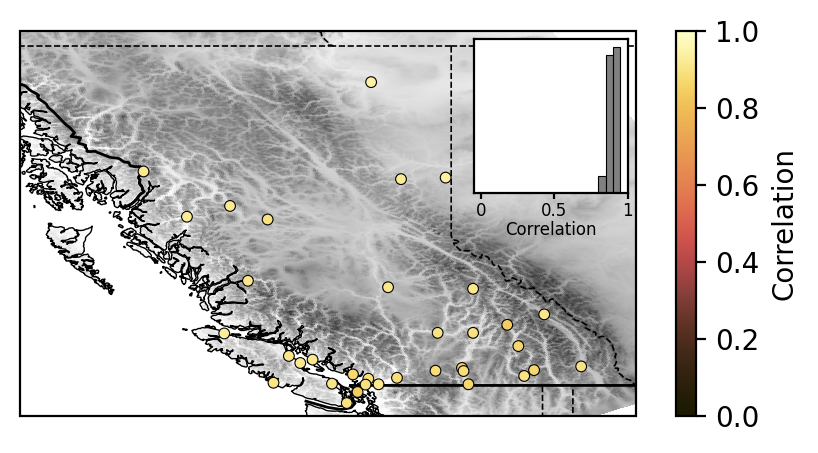

In [13]:
# plot
fig = plt.figure(dpi=200, figsize=(13, 2.5))

lon = wrf_static['XLONG'].values.squeeze()
lat = wrf_static['XLAT'].values.squeeze()

ax0 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
lat, lon = stn_latlon[stn]
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)

lons = []
lats = []
corrs = []
for stn_coords, corr in corr_dict.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    corrs.append(corr)
# Sort
corrs, lats, lons = sort_data(corrs, lats, lons)

scatter = ax0.scatter(
    lons, lats,
    c=corrs,
    s=15,
    cmap=cm.lajolla,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0.,
    vmax=1.,
)

axins = inset_axes(ax0, width="25%", height="40%", loc='upper right', borderpad=0.3)
axins.hist(corrs, bins=np.arange(0,1,.05), color='gray', edgecolor='black', linewidth=.4)
axins.set_xlabel('Correlation', fontsize=6, labelpad=.5)
axins.tick_params(axis='both', which='major', labelsize=6, size=2)
axins.set_xticks([0,.5,1])
axins.set_xticklabels([0,.5,1], fontsize=6)
axins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
axins.set_yticks([])

# lon = topography['XLONG'].squeeze()
# lat = topography['XLAT'].squeeze()
# hgt = topography['HGT'].squeeze()
# subax = inset_axes(
#     ax0,
#     width="30%", height="43.3%",
#     loc='lower left',
#     borderpad=0.,
#     axes_class=cgeo.GeoAxes,
#     axes_kwargs=dict(map_projection=ccrs.PlateCarree()),
# )
# scatter_sub = subax.scatter(
#     lons, lats,
#     c=corrs,
#     s=15,
#     cmap='inferno',
#     edgecolor='k',
#     linewidth=0.4,
#     marker='o',
#     transform=ccrs.PlateCarree(),
#     zorder=3,
#     vmin=0,
#     vmax=0.7
# )
# subax.set_xlim(-124.2, -122)
# subax.set_ylim(48, 50)
# subax.coastlines(linewidth=0.5, zorder=2)
# mesh = subax.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='Greys')

cbar = plt.colorbar(scatter, ax=ax0, orientation='vertical', pad=0.02)
cbar.set_label('Correlation')

min=0.90 max=1.83


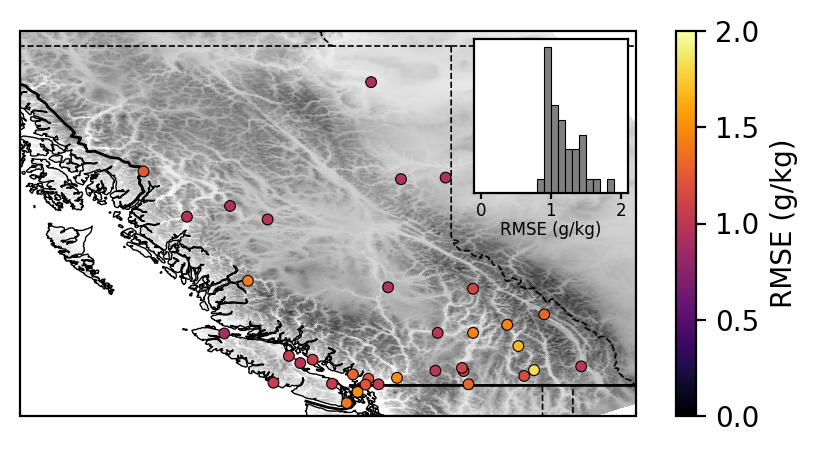

In [14]:
# plot
fig = plt.figure(dpi=200, figsize=(13, 2.5))

lon = wrf_static['XLONG'].values.squeeze()
lat = wrf_static['XLAT'].values.squeeze()

ax0 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
lat, lon = stn_latlon[stn]
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)

lons = []
lats = []
rmses = []
for stn_coords, rmse in rmse_dict.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    rmses.append(rmse)
# Sort
rmses, lats, lons = sort_data(rmses, lats, lons)

scatter = ax0.scatter(
    lons, lats,
    c=rmses,
    s=15,
    cmap='inferno',
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=2.
)

print(f'min={min(rmses):.2f}',f'max={max(rmses):.2f}')
axins = inset_axes(ax0, width="25%", height="40%", loc='upper right', borderpad=0.3)
axins.hist(rmses, bins=np.arange(0,2.1,.1), color='gray', edgecolor='black', linewidth=.4)
axins.set_xlabel('RMSE (g/kg)', fontsize=6, labelpad=.5)
axins.tick_params(axis='both', which='major', labelsize=6, size=2)
axins.set_xticks([0,1,2])
axins.set_xticklabels([0,1,2], fontsize=6)
axins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
axins.set_yticks([])

cbar = plt.colorbar(scatter, ax=ax0, orientation='vertical', pad=0.02)
cbar.set_label('RMSE (g/kg)')

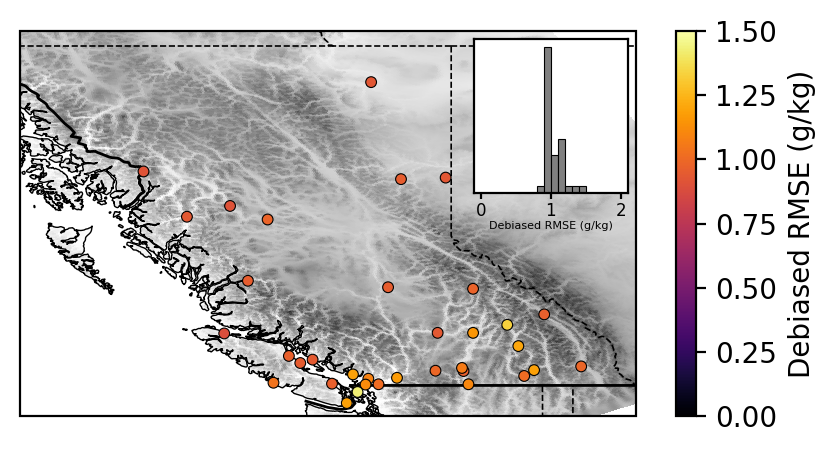

In [15]:
# plot
fig = plt.figure(dpi=200, figsize=(13, 2.5))

lon = wrf_static['XLONG'].values.squeeze()
lat = wrf_static['XLAT'].values.squeeze()

ax0 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
lat, lon = stn_latlon[stn]
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)

lons = []
lats = []
urmses = []
for stn_coords, urmse in urmse_dict.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    urmses.append(urmse)
# Sort
urmses, lats, lons = sort_data(urmses, lats, lons)

scatter = ax0.scatter(
    lons, lats,
    c=urmses,
    s=15,
    cmap='inferno',
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=1.5
)

axins = inset_axes(ax0, width="25%", height="40%", loc='upper right', borderpad=0.3)
axins.hist(urmses, bins=np.arange(0,2.1,.1), color='gray', edgecolor='black', linewidth=.4)
axins.set_xlabel('Debiased RMSE (g/kg)', fontsize=4, labelpad=.5)
axins.tick_params(axis='both', which='major', labelsize=6, size=2)
axins.set_xticks([0,1,2])
axins.set_xticklabels([0,1,2], fontsize=6)
axins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
axins.set_yticks([])

cbar = plt.colorbar(scatter, ax=ax0, orientation='vertical', pad=0.02)
cbar.set_label('Debiased RMSE (g/kg)')

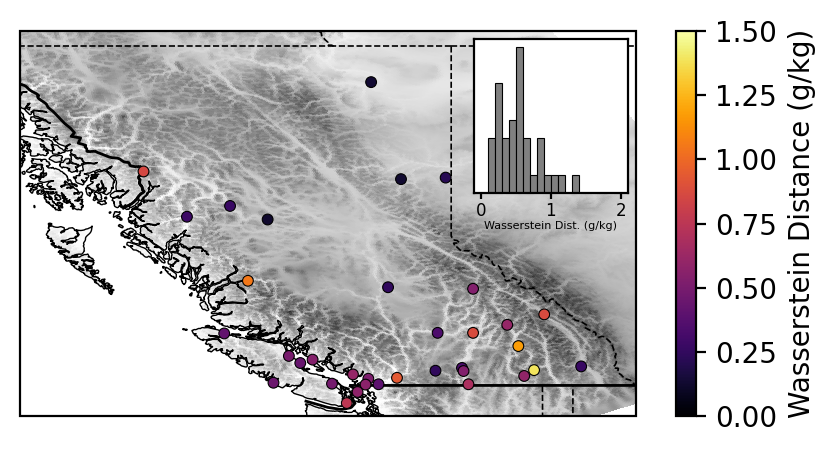

In [16]:
# plot
fig = plt.figure(dpi=200, figsize=(13, 2.5))

lon = wrf_static['XLONG'].values.squeeze()
lat = wrf_static['XLAT'].values.squeeze()

ax0 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
lat, lon = stn_latlon[stn]
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)

lons = []
lats = []
WDs = []
for stn_coords, wass in wass_dict.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    WDs.append(wass)
# Sort
WDs, lats, lons = sort_data(WDs, lats, lons)

scatter = ax0.scatter(
    lons, lats,
    c=WDs,
    s=15,
    cmap='inferno',
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=1.5,
)


axins = inset_axes(ax0, width="25%", height="40%", loc='upper right', borderpad=0.3)
axins.hist(WDs, bins=np.arange(0,2.1,.1), color='gray', edgecolor='black', linewidth=.4)
axins.set_xlabel('Wasserstein Dist. (g/kg)', fontsize=4, labelpad=.5)
axins.tick_params(axis='both', which='major', labelsize=6, size=2)
axins.set_xticks([0,1,2])
axins.set_xticklabels([0,1,2], fontsize=6)
axins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
axins.set_yticks([])

cbar = plt.colorbar(scatter, ax=ax0, orientation='vertical', pad=0.02)
cbar.set_label('Wasserstein Distance (g/kg)')

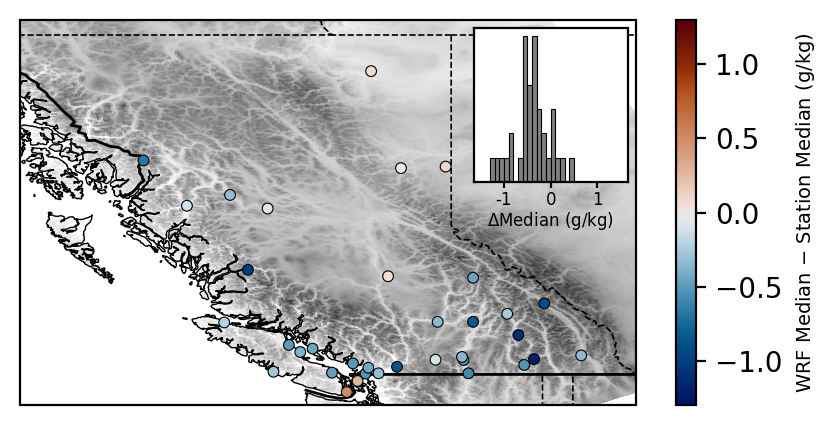

In [17]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# plot
fig = plt.figure(dpi=200, figsize=(13, 2.5))

lon = wrf_static['XLONG'].values.squeeze()
lat = wrf_static['XLAT'].values.squeeze()

ax0 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
lat, lon = stn_latlon[stn]
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)

lons = []
lats = []
bias_medians = []
for stn_coords, bmedian in bmedian_dict.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    bias_medians.append(bmedian)
# Sort
bias_medians, lats, lons = sort_data(bias_medians, lats, lons)

scatter = ax0.scatter(
    lons, lats,
    c=bias_medians,
    s=15,
    cmap=cm.vik,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=-1.3,
    vmax=1.3,
)

axins = inset_axes(ax0, width="25%", height="40%", loc='upper right', borderpad=0.3)
axins.hist(bias_medians, bins=np.arange(-1.5,1.6,.1), color='gray', edgecolor='black', linewidth=.4)
axins.set_xlabel('$\Delta$Median (g/kg)', fontsize=6, labelpad=.5)
axins.tick_params(axis='both', which='major', labelsize=6, size=2)
axins.set_xticks([-1,0,1])
axins.set_xticklabels([-1,0,1], fontsize=6)
axins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
axins.set_yticks([])

cbar = plt.colorbar(scatter, ax=ax0, orientation='vertical', pad=0.02)
cbar.set_label('WRF Median $-$ Station Median (g/kg)', fontsize=7)

plt.show()

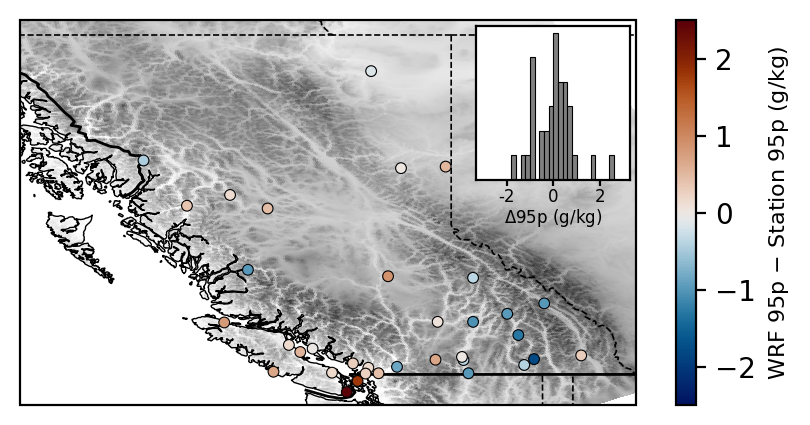

In [18]:
# plot
fig = plt.figure(dpi=200, figsize=(13, 2.5))

lon = wrf_static['XLONG'].values.squeeze()
lat = wrf_static['XLAT'].values.squeeze()

ax0 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
lat, lon = stn_latlon[stn]
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)

lons = []
lats = []
bias_95p = []
for stn_coords, b95 in b95p_dict.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    bias_95p.append(b95)
# Sort
bias_95p, lats, lons = sort_data(bias_95p, lats, lons)

scatter = ax0.scatter(
    lons, lats,
    c=bias_95p,
    s=15,
    cmap=cm.vik,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=-2.5,
    vmax=2.5,
)

axins = inset_axes(ax0, width="25%", height="40%", loc='upper right', borderpad=0.2)
axins.hist(bias_95p, bins=np.arange(-3, 3+.2, .2), color='gray', edgecolor='black', linewidth=.4)
axins.set_xlabel('$\Delta$95p (g/kg)', fontsize=6, labelpad=.5)
axins.tick_params(axis='both', which='major', labelsize=6, size=2)
axins.set_xticks([-2,0,2])
axins.set_xticklabels([-2,0,2], fontsize=6)
axins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
axins.set_yticks([])

cbar = plt.colorbar(scatter, ax=ax0, orientation='vertical', pad=0.02)
cbar.set_label('WRF 95p $-$ Station 95p (g/kg)', fontsize=8)

# Seasonal Plots

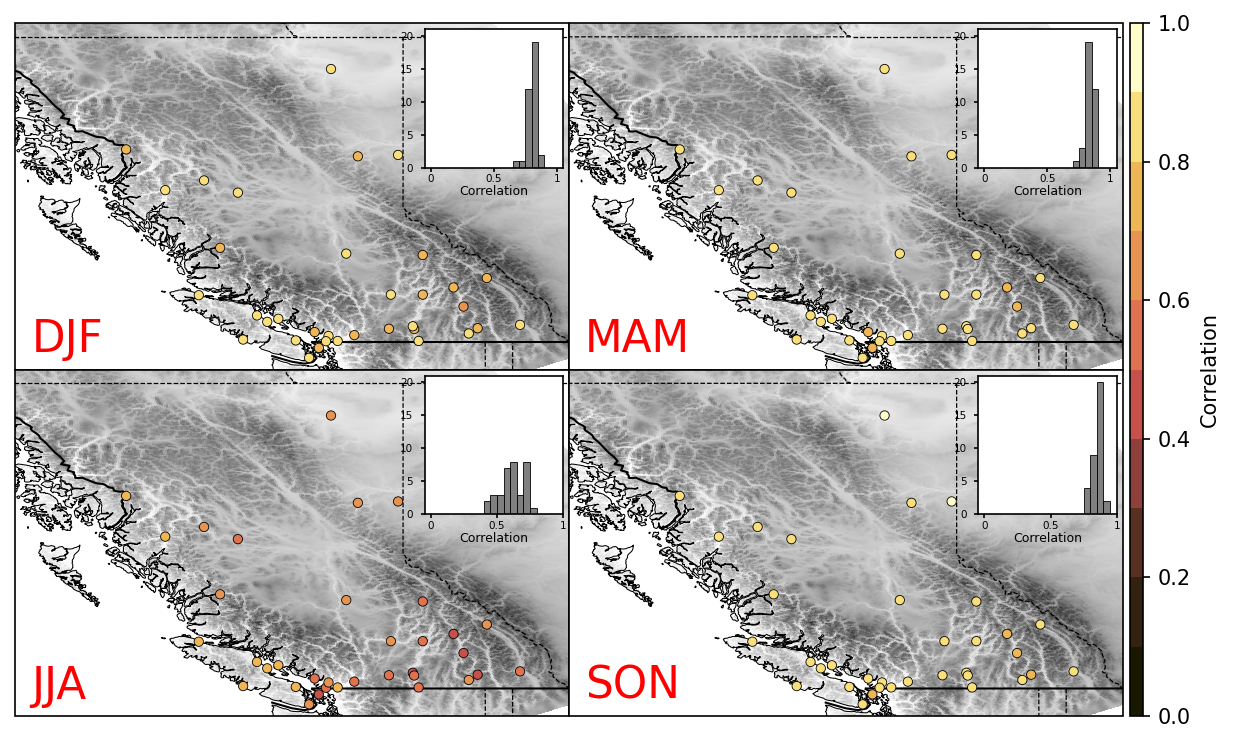

In [19]:
fig = plt.figure(figsize=(11.475,6),dpi=150)

# Create a discrete colormap with 20 steps from inferno
cmap = ListedColormap(cm.lajolla(np.linspace(0, 1, 10)))

N = 21
lon = wrf_static['XLONG'].values.squeeze()
lat = wrf_static['XLAT'].values.squeeze()
ax0 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)
ax1 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
mesh = ax1.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax1.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax1.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax1.set_xlim(-134, -114)
ax1.set_ylim(48, 60.5)
ax1.coastlines(linewidth=0.5, zorder=2)
ax2 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
mesh = ax2.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax2.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax2.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax2.set_xlim(-134, -114)
ax2.set_ylim(48, 60.5)
ax2.coastlines(linewidth=0.5, zorder=2)
ax3 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree())
mesh = ax3.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax3.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax3.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax3.set_xlim(-134, -114)
ax3.set_ylim(48, 60.5)
ax3.coastlines(linewidth=0.5, zorder=2)

lons, lats, corrs = [], [], []
for stn_coords, corr in corr_dict_DJF.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    corrs.append(corr)
corrs, lats, lons = sort_data(corrs, lats, lons)

ax0.text(0.03, 0.05, "DJF", color='red', fontsize=21, transform=ax0.transAxes)
scatter0 = ax0.scatter(
    lons, lats,
    c=corrs,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=1
)
ax0ins = inset_axes(ax0, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax0ins.hist(corrs, bins=np.arange(0,1.05,.05), color='gray', edgecolor='black', linewidth=.4)
ax0ins.set_xlabel('Correlation', fontsize=6, labelpad=.5)
ax0ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax0ins.set_xticks([0,.5,1])
ax0ins.set_xticklabels([0,.5,1], fontsize=5)
ax0ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax0ins.set_ylim(0,N)
# ax0ins.set_yticks([])

lons, lats, corrs = [], [], []
for stn_coords, corr in corr_dict_MAM.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    corrs.append(corr)
corrs, lats, lons = sort_data(corrs, lats, lons)
ax1.text(0.03, 0.05, "MAM", color='red', fontsize=21, transform=ax1.transAxes)
scatter1 = ax1.scatter(
    lons, lats,
    c=corrs,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=1
)
ax1ins = inset_axes(ax1, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax1ins.hist(corrs, bins=np.arange(0,1.05,.05), color='gray', edgecolor='black', linewidth=.4)
ax1ins.set_xlabel('Correlation', fontsize=6, labelpad=.5)
ax1ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax1ins.set_xticks([0,.5,1])
ax1ins.set_xticklabels([0,.5,1], fontsize=5)
ax1ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax1ins.set_ylim(0,N)
# ax1ins.set_yticks([])

lons, lats, corrs = [], [], []
for stn_coords, corr in corr_dict_JJA.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    corrs.append(corr)
corrs, lats, lons = sort_data(corrs, lats, lons)
ax2.text(0.03, 0.05, "JJA", color='red', fontsize=21, transform=ax2.transAxes)
scatter2 = ax2.scatter(
    lons, lats,
    c=corrs,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=1
)
ax2ins = inset_axes(ax2, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax2ins.hist(corrs, bins=np.arange(0,1,.05), color='gray', edgecolor='black', linewidth=.4)
ax2ins.set_xlabel('Correlation', fontsize=6, labelpad=.5)
ax2ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax2ins.set_xticks([0,.5,1])
ax2ins.set_xticklabels([0,.5,1], fontsize=5)
ax2ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax2ins.set_ylim(0,N)
# ax2ins.set_yticks([])

lons, lats, corrs = [], [], []
for stn_coords, corr in corr_dict_SON.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    corrs.append(corr)
corrs, lats, lons = sort_data(corrs, lats, lons)
ax3.text(0.03, 0.05, "SON", color='red', fontsize=21, transform=ax3.transAxes)
scatter3 = ax3.scatter(
    lons, lats,
    c=corrs,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=1
)
ax3ins = inset_axes(ax3, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax3ins.hist(corrs, bins=np.arange(0,1,.05), color='gray', edgecolor='black', linewidth=.4,)
ax3ins.set_xlabel('Correlation', fontsize=6, labelpad=.5)
ax3ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax3ins.set_xticks([0,.5,1])
ax3ins.set_xticklabels([0,.5,1], fontsize=5)
ax3ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax3ins.set_ylim(0,N)
# ax3ins.set_yticks([])

plt.subplots_adjust(wspace=-.035, hspace=-0)
cbar = plt.colorbar(scatter0, ax=[ax0,ax1,ax2,ax3], orientation='vertical', pad=0.005, shrink=1, aspect=50)
cbar.set_label('Correlation')
plt.show()

DJF: min=0.11 max=0.99
MAM: min=0.13 max=1.09
JJA: min=0.12 max=1.78
SON: min=0.17 max=1.74


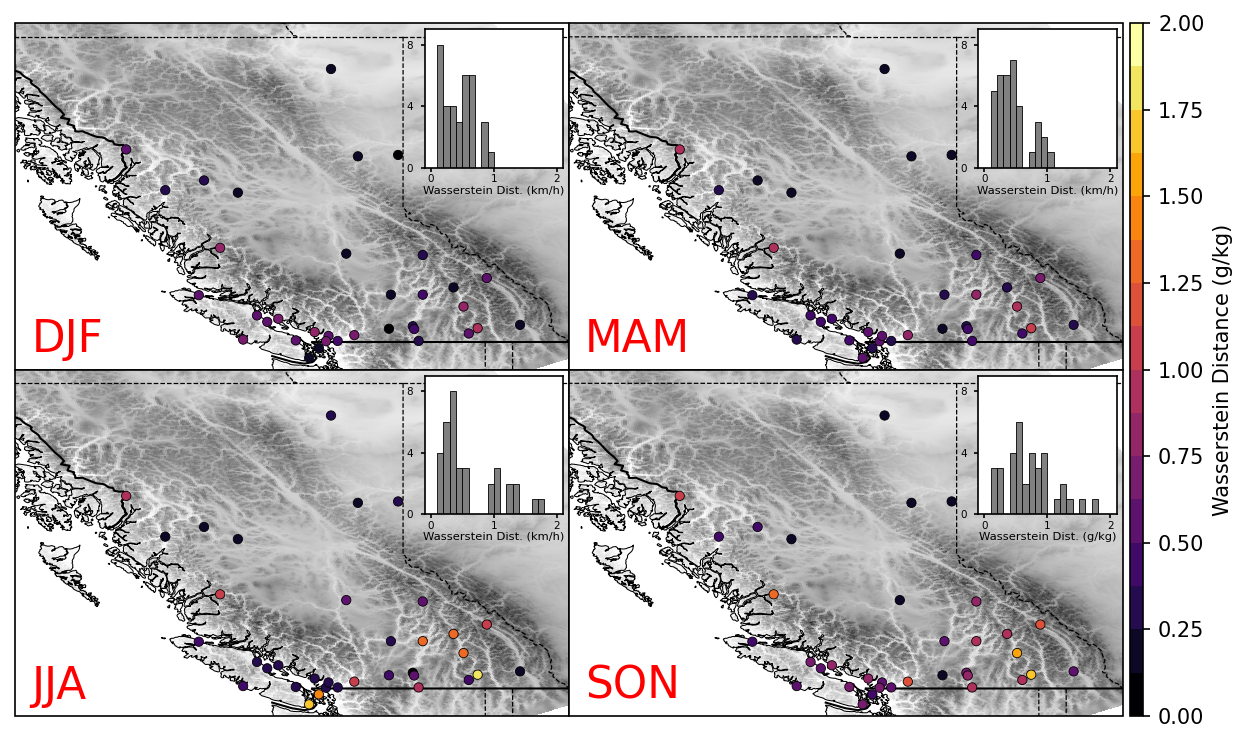

In [20]:
fig = plt.figure(figsize=(11.475,6),dpi=150)

# Create a discrete colormap with 16 steps from inferno
cmap = ListedColormap(plt.cm.inferno(np.linspace(0, 1, 16)))
N = 9
bins = np.arange(0,2.1,.1)
xticks = [0,1,2,]
yticks = [0,4,8]
vmax = 2
lon = wrf_static['XLONG'].values.squeeze()
lat = wrf_static['XLAT'].values.squeeze()
ax0 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)
ax1 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
mesh = ax1.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax1.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax1.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax1.set_xlim(-134, -114)
ax1.set_ylim(48, 60.5)
ax1.coastlines(linewidth=0.5, zorder=2)
ax2 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
mesh = ax2.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax2.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax2.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax2.set_xlim(-134, -114)
ax2.set_ylim(48, 60.5)
ax2.coastlines(linewidth=0.5, zorder=2)
ax3 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree())
mesh = ax3.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax3.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax3.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax3.set_xlim(-134, -114)
ax3.set_ylim(48, 60.5)
ax3.coastlines(linewidth=0.5, zorder=2)

lons, lats, WDs = [], [], []
for stn_coords, wass in wass_dict_DJF.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    WDs.append(wass)
# Sort
WDs, lats, lons = sort_data(WDs, lats, lons)
print('DJF:',f'min={min(WDs):.2f}',f'max={max(WDs):.2f}')
ax0.text(0.03, 0.05, "DJF", color='red', fontsize=21, transform=ax0.transAxes)
scatter0 = ax0.scatter(
    lons, lats,
    c=WDs,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=vmax,
)
ax0ins = inset_axes(ax0, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax0ins.hist(WDs, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax0ins.set_xlabel('Wasserstein Dist. (km/h)', fontsize=5.5, labelpad=.5)
ax0ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax0ins.set_xticks(xticks)
ax0ins.set_xticklabels(xticks, fontsize=5)
ax0ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax0ins.set_ylim(0,N)
ax0ins.set_yticks(yticks)

lons, lats, WDs = [], [], []
for stn_coords, wass in wass_dict_MAM.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    WDs.append(wass)
WDs, lats, lons = sort_data(WDs, lats, lons)
print('MAM:',f'min={min(WDs):.2f}',f'max={max(WDs):.2f}')
ax1.text(0.03, 0.05, "MAM", color='red', fontsize=21, transform=ax1.transAxes)
scatter1 = ax1.scatter(
    lons, lats,
    c=WDs,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=vmax
)
ax1ins = inset_axes(ax1, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax1ins.hist(WDs, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax1ins.set_xlabel('Wasserstein Dist. (km/h)', fontsize=5.5, labelpad=.5)
ax1ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax1ins.set_xticks(xticks)
ax1ins.set_xticklabels(xticks, fontsize=5)
ax1ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax1ins.set_ylim(0,N)
ax1ins.set_yticks(yticks)

lons, lats, WDs = [], [], []
for stn_coords, wass in wass_dict_JJA.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    WDs.append(wass)
WDs, lats, lons = sort_data(WDs, lats, lons)
print('JJA:',f'min={min(WDs):.2f}',f'max={max(WDs):.2f}')
ax2.text(0.03, 0.05, "JJA", color='red', fontsize=21, transform=ax2.transAxes)
scatter2 = ax2.scatter(
    lons, lats,
    c=WDs,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=vmax
)
ax2ins = inset_axes(ax2, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax2ins.hist(WDs, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax2ins.set_xlabel('Wasserstein Dist. (km/h)', fontsize=5.5, labelpad=.5)
ax2ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax2ins.set_xticks(xticks)
ax2ins.set_xticklabels(xticks, fontsize=5)
ax2ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax2ins.set_ylim(0,N)
ax2ins.set_yticks(yticks)

lons, lats, WDs = [], [], []
for stn_coords, wass in wass_dict_SON.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    WDs.append(wass)
WDs, lats, lons = sort_data(WDs, lats, lons)
print('SON:',f'min={min(WDs):.2f}',f'max={max(WDs):.2f}')
ax3.text(0.03, 0.05, "SON", color='red', fontsize=21, transform=ax3.transAxes)
scatter3 = ax3.scatter(
    lons, lats,
    c=WDs,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=vmax
)
ax3ins = inset_axes(ax3, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax3ins.hist(WDs, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax3ins.set_xlabel('Wasserstein Dist. (g/kg)', fontsize=5.5, labelpad=.5)
ax3ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax3ins.set_xticks(xticks)
ax3ins.set_xticklabels(xticks, fontsize=5)
ax3ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax3ins.set_ylim(0,N)
ax3ins.set_yticks(yticks)

plt.subplots_adjust(wspace=-.035, hspace=-0)
cbar = plt.colorbar(scatter0, ax=[ax0,ax1,ax2,ax3], orientation='vertical', pad=0.005, shrink=1, aspect=50)
cbar.set_label('Wasserstein Distance (g/kg)')
plt.show()

DJF: min=-1.14 max=0.22
MAM: min=-1.11 max=0.32
JJA: min=-1.81 max=1.34
SON: min=-1.68 max=0.64


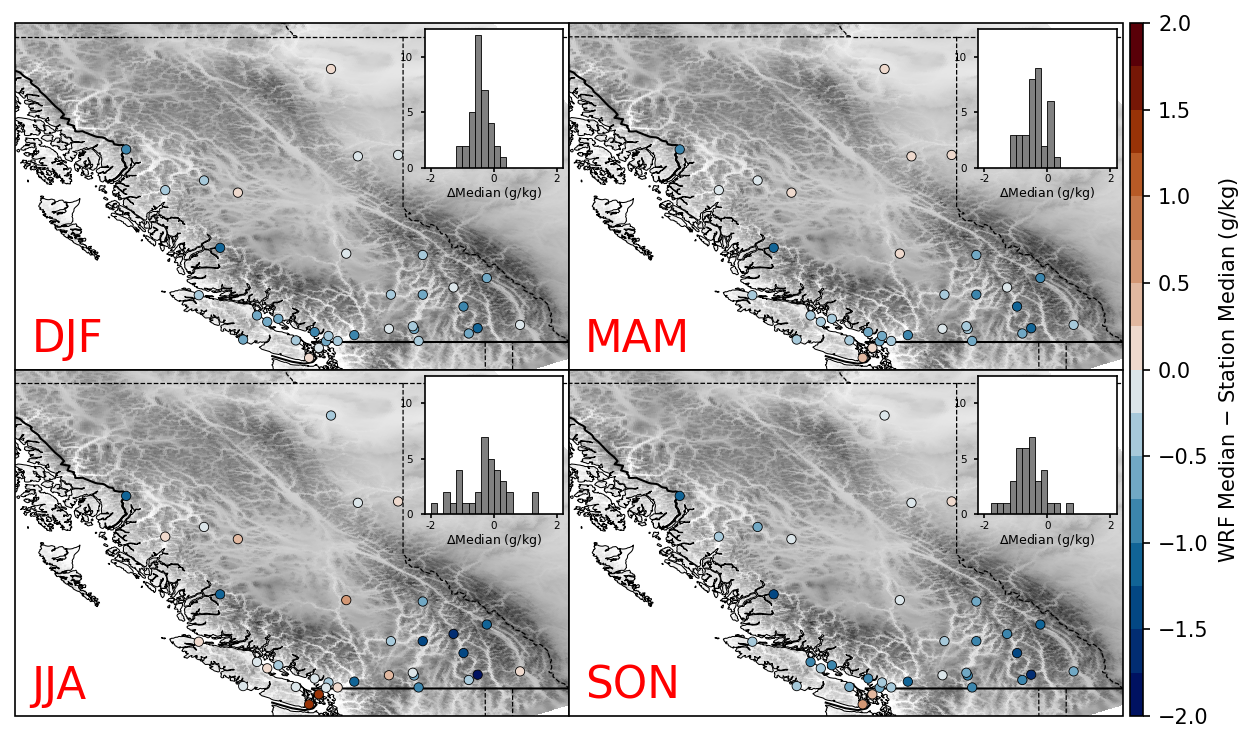

In [21]:
fig = plt.figure(figsize=(11.475,6),dpi=150)

# Create a discrete colormap with 25 steps from inferno
cmap = ListedColormap(cm.vik(np.linspace(0, 1, 16)))
N = 12.5
bins = np.arange(-2,2.2,.2)
xticks = [-2,0,2]
yticks = [0,5,10]
vmax = 2

lon = wrf_static['XLONG'].values.squeeze()
lat = wrf_static['XLAT'].values.squeeze()
ax0 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)
ax1 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
mesh = ax1.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax1.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax1.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax1.set_xlim(-134, -114)
ax1.set_ylim(48, 60.5)
ax1.coastlines(linewidth=0.5, zorder=2)
ax2 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
mesh = ax2.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax2.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax2.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax2.set_xlim(-134, -114)
ax2.set_ylim(48, 60.5)
ax2.coastlines(linewidth=0.5, zorder=2)
ax3 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree())
mesh = ax3.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax3.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax3.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax3.set_xlim(-134, -114)
ax3.set_ylim(48, 60.5)
ax3.coastlines(linewidth=0.5, zorder=2)

lons, lats, bmedians = [], [], []
for stn_coords, bmedian in bmedian_dict_DJF.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    bmedians.append(bmedian)
print('DJF:',f'min={min(bmedians):.2f}',f'max={max(bmedians):.2f}')
bmedians, lats, lons = sort_data(bmedians, lats, lons)
ax0.text(0.03, 0.05, "DJF", color='red', fontsize=21, transform=ax0.transAxes)
scatter0 = ax0.scatter(
    lons, lats,
    c=bmedians,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=-vmax,
    vmax=vmax
)
ax0ins = inset_axes(ax0, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax0ins.hist(bmedians, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax0ins.set_xlabel('$\Delta$Median (g/kg)', fontsize=6, labelpad=.5)
ax0ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax0ins.set_xticks(xticks)
ax0ins.set_xticklabels(xticks, fontsize=5)
ax0ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax0ins.set_ylim(0,N)
ax0ins.set_yticks(yticks)

lons, lats, bmedians = [], [], []
for stn_coords, bmedian in bmedian_dict_MAM.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    bmedians.append(bmedian)
bmedians, lats, lons = sort_data(bmedians, lats, lons)
print('MAM:',f'min={min(bmedians):.2f}',f'max={max(bmedians):.2f}')
ax1.text(0.03, 0.05, "MAM", color='red', fontsize=21, transform=ax1.transAxes)
scatter1 = ax1.scatter(
    lons, lats,
    c=bmedians,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=-vmax,
    vmax=vmax
)
ax1ins = inset_axes(ax1, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax1ins.hist(bmedians, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax1ins.set_xlabel('$\Delta$Median (g/kg)', fontsize=6, labelpad=.5)
ax1ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax1ins.set_xticks(xticks)
ax1ins.set_xticklabels(xticks, fontsize=5)
ax1ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax1ins.set_ylim(0,N)
ax1ins.set_yticks(yticks)

lons, lats, bmedians = [], [], []
for stn_coords, bmedian in bmedian_dict_JJA.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    bmedians.append(bmedian)
bmedians, lats, lons = sort_data(bmedians, lats, lons)
print('JJA:',f'min={min(bmedians):.2f}',f'max={max(bmedians):.2f}')
ax2.text(0.03, 0.05, "JJA", color='red', fontsize=21, transform=ax2.transAxes)
scatter2 = ax2.scatter(
    lons, lats,
    c=bmedians,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=-vmax,
    vmax=vmax
)
ax2ins = inset_axes(ax2, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax2ins.hist(bmedians, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax2ins.set_xlabel('$\Delta$Median (g/kg)', fontsize=6, labelpad=.5)
ax2ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax2ins.set_xticks(xticks)
ax2ins.set_xticklabels(xticks, fontsize=5)
ax2ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax2ins.set_ylim(0,N)
ax2ins.set_yticks(yticks)

lons, lats, bmedians = [], [], []
for stn_coords, bmedian in bmedian_dict_SON.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    bmedians.append(bmedian)
bmedians, lats, lons = sort_data(bmedians, lats, lons)
print('SON:',f'min={min(bmedians):.2f}',f'max={max(bmedians):.2f}')
ax3.text(0.03, 0.05, "SON", color='red', fontsize=21, transform=ax3.transAxes)
scatter3 = ax3.scatter(
    lons, lats,
    c=bmedians,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=-vmax,
    vmax=vmax
)
ax3ins = inset_axes(ax3, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax3ins.hist(bmedians, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax3ins.set_xlabel('$\Delta$Median (g/kg)', fontsize=6, labelpad=.5)
ax3ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax3ins.set_xticks(xticks)
ax3ins.set_xticklabels(xticks, fontsize=5)
ax3ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax3ins.set_ylim(0,N)
ax3ins.set_yticks(yticks)

plt.subplots_adjust(wspace=-.035, hspace=-0)
cbar = plt.colorbar(scatter0, ax=[ax0,ax1,ax2,ax3], orientation='vertical', pad=0.005, shrink=1, aspect=50)
cbar.set_ticks(np.arange(-vmax,vmax+.5,.5))
cbar.set_label('WRF Median $-$ Station Median (g/kg)',)
plt.show()

DJF: min=-0.89 max=0.56
MAM: min=-0.97 max=1.55
JJA: min=-2.06 max=3.38
SON: min=-2.07 max=1.96


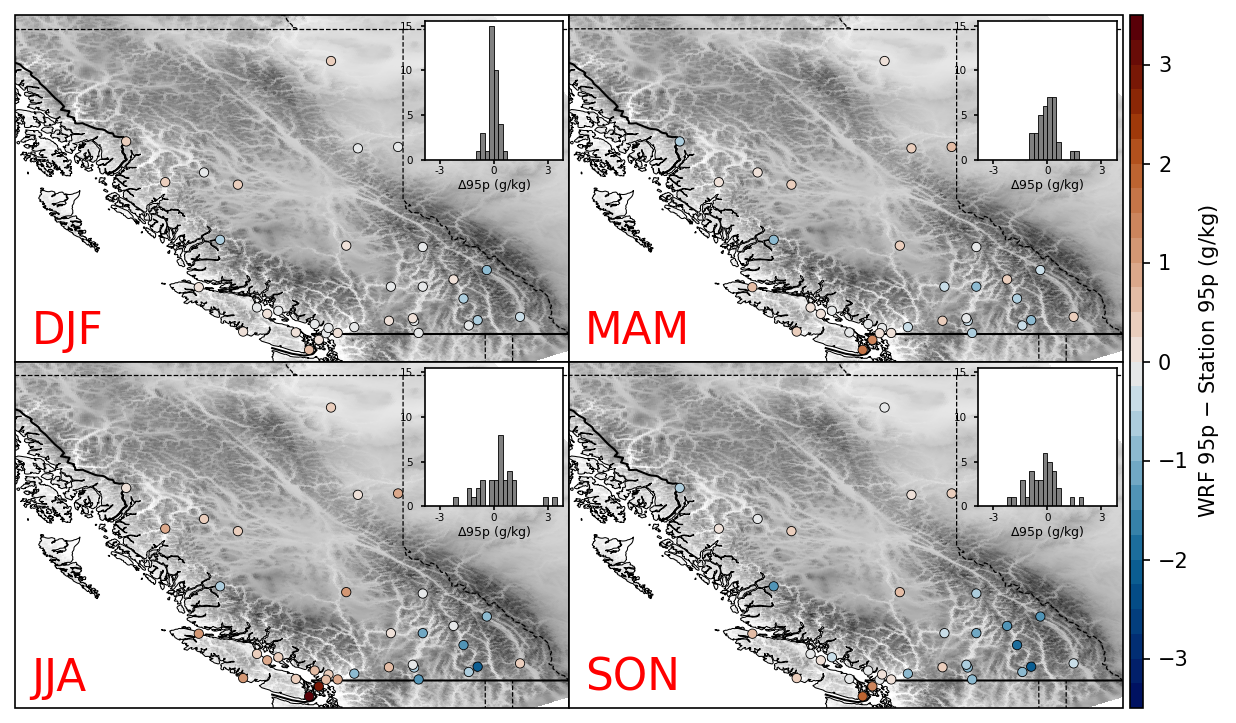

In [22]:
fig = plt.figure(figsize=(11.475,6),dpi=150)

# Create a discrete colormap with 25 steps from inferno
cmap = ListedColormap(cm.vik(np.linspace(0, 1, 28)))
N = 15.5
bins = np.arange(-3.5,3.75,.25)
xticks = [-3,0,3]
yticks = [0,5,10,15]
vmax = 3.5

lon = wrf_static['XLONG'].values.squeeze()
lat = wrf_static['XLAT'].values.squeeze()
ax0 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)
ax1 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
mesh = ax1.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax1.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax1.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax1.set_xlim(-134, -114)
ax1.set_ylim(48, 60.5)
ax1.coastlines(linewidth=0.5, zorder=2)
ax2 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
mesh = ax2.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax2.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax2.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax2.set_xlim(-134, -114)
ax2.set_ylim(48, 60.5)
ax2.coastlines(linewidth=0.5, zorder=2)
ax3 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree())
mesh = ax3.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax3.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax3.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax3.set_xlim(-134, -114)
ax3.set_ylim(48, 60.5)
ax3.coastlines(linewidth=0.5, zorder=2)

lons, lats, b95ps = [], [], []
for stn_coords, b95p in b95p_dict_DJF.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    b95ps.append(b95p)
b95ps, lats, lons = sort_data(b95ps, lats, lons)
print('DJF:',f'min={min(b95ps):.2f}',f'max={max(b95ps):.2f}')
ax0.text(0.03, 0.05, "DJF", color='red', fontsize=21, transform=ax0.transAxes)
scatter0 = ax0.scatter(
    lons, lats,
    c=b95ps,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=-vmax,
    vmax=vmax
)
ax0ins = inset_axes(ax0, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax0ins.hist(b95ps, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax0ins.set_xlabel('$\Delta$95p (g/kg)', fontsize=6, labelpad=.5)
ax0ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax0ins.set_xticks(xticks)
ax0ins.set_xticklabels(xticks, fontsize=5)
ax0ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax0ins.set_ylim(0,N)
ax0ins.set_yticks(yticks)

lons, lats, b95ps = [], [], []
for stn_coords, b95p in b95p_dict_MAM.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    b95ps.append(b95p)
b95ps, lats, lons = sort_data(b95ps, lats, lons)
print('MAM:',f'min={min(b95ps):.2f}',f'max={max(b95ps):.2f}')
ax1.text(0.03, 0.05, "MAM", color='red', fontsize=21, transform=ax1.transAxes)
scatter1 = ax1.scatter(
    lons, lats,
    c=b95ps,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=-vmax,
    vmax=vmax
)
ax1ins = inset_axes(ax1, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax1ins.hist(b95ps, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax1ins.set_xlabel('$\Delta$95p (g/kg)', fontsize=6, labelpad=.5)
ax1ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax1ins.set_xticks(xticks)
ax1ins.set_xticklabels(xticks, fontsize=5)
ax1ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax1ins.set_ylim(0,N)
ax1ins.set_yticks(yticks)

lons, lats, b95ps = [], [], []
for stn_coords, b95p in b95p_dict_JJA.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    b95ps.append(b95p)
b95ps, lats, lons = sort_data(b95ps, lats, lons)
print('JJA:',f'min={min(b95ps):.2f}',f'max={max(b95ps):.2f}')
ax2.text(0.03, 0.05, "JJA", color='red', fontsize=21, transform=ax2.transAxes)
scatter2 = ax2.scatter(
    lons, lats,
    c=b95ps,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=-vmax,
    vmax=vmax
)
ax2ins = inset_axes(ax2, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax2ins.hist(b95ps, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax2ins.set_xlabel('$\Delta$95p (g/kg)', fontsize=6, labelpad=.5)
ax2ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax2ins.set_xticks(xticks)
ax2ins.set_xticklabels(xticks, fontsize=5)
ax2ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax2ins.set_ylim(0,N)
ax2ins.set_yticks(yticks)

lons, lats, b95ps = [], [], []
for stn_coords, b95p in b95p_dict_SON.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    b95ps.append(b95p)
b95ps, lats, lons = sort_data(b95ps, lats, lons)
print('SON:',f'min={min(b95ps):.2f}',f'max={max(b95ps):.2f}')
ax3.text(0.03, 0.05, "SON", color='red', fontsize=21, transform=ax3.transAxes)
scatter3 = ax3.scatter(
    lons, lats,
    c=b95ps,
    s=20,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=-vmax,
    vmax=vmax
)
ax3ins = inset_axes(ax3, width="25%", height="40%", loc='upper right', borderpad=0.3)
ax3ins.hist(b95ps, bins=bins, color='gray', edgecolor='black', linewidth=.4,)
ax3ins.set_xlabel('$\Delta$95p (g/kg)', fontsize=6, labelpad=.5)
ax3ins.tick_params(axis='both', which='major', labelsize=5, size=2)
ax3ins.set_xticks(xticks)
ax3ins.set_xticklabels(xticks, fontsize=5)
ax3ins.xaxis.set_tick_params(pad=1)  # smaller pad moves labels closer to axis
ax3ins.set_ylim(0,N)
ax3ins.set_yticks(yticks)

plt.subplots_adjust(wspace=-.035, hspace=-0)
cbar = plt.colorbar(scatter0, ax=[ax0,ax1,ax2,ax3], orientation='vertical', pad=0.005, shrink=1, aspect=50)
cbar.set_label('WRF 95p $-$ Station 95p (g/kg)',)
plt.show()

# Taylor Diagram

(1/36) Working on ABBOTSFORD A...
(2/36) Working on AGASSIZ RCS...
(3/36) Working on BELLA COOLA A...
(4/36) Working on BLUE RIVER A...
(5/36) Working on BLUE RIVER CS...
(6/36) Working on BURNS LAKE DECKER LAKE...
(7/36) Working on CAMPBELL RIVER A...
(8/36) Working on CASTLEGAR A...
(9/36) Working on CHETWYND A...
(10/36) Working on COMOX A...
(11/36) Working on CRANBROOK A...
(12/36) Working on DAWSON CREEK A...
(13/36) Working on FORT NELSON A...
(14/36) Working on GOLDEN A...
(15/36) Working on KAMLOOPS A...
(16/36) Working on NAKUSP CS...
(17/36) Working on NANAIMO A...
(18/36) Working on NELSON CS...
(19/36) Working on OSOYOOS CS...
(20/36) Working on PENTICTON A...
(21/36) Working on PITT MEADOWS CS...
(22/36) Working on PORT HARDY A...
(23/36) Working on POWELL RIVER A...
(24/36) Working on PRINCETON A...
(25/36) Working on REVELSTOKE A...
(26/36) Working on SALMON ARM CS...
(27/36) Working on SATURNA ISLAND CS...
(28/36) Working on SMITHERS A...
(29/36) Working on STEWART A..

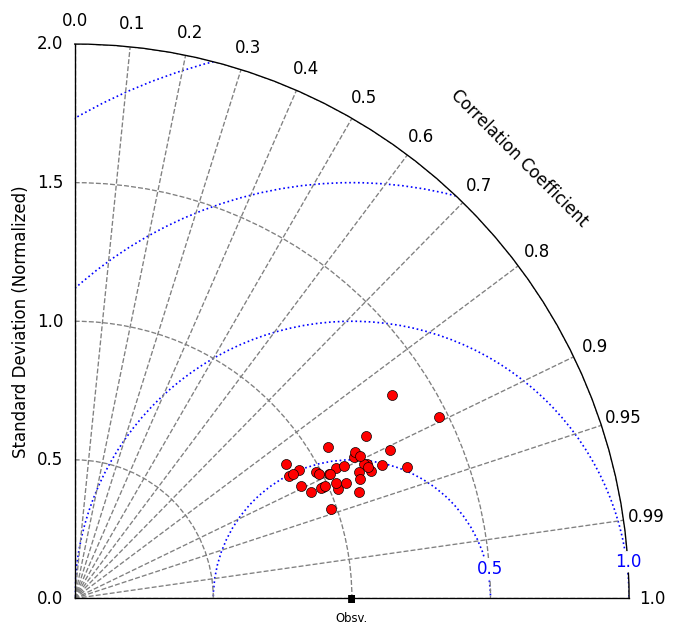

In [23]:
# Set up the plot

fig = plt.figure(figsize=(6, 6), dpi=120)
ax = fig.add_subplot(111, polar=True)

rlim = 2.0
dr = .5
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rlabel_position(225)
ax.set_ylabel('Standard Deviation (Normalized)')
ax.set_yticks(np.arange(0, rlim + dr, dr))
ax.set_ylim(0, rlim)
ax.set_thetamin(0)
ax.set_thetamax(90)

corr_ticklabels = np.array([0,1,2,3,4,5,6,7,8,9,9.5,9.9,10])/10.
corr_ticks = np.arcsin(corr_ticklabels)
ax.set_thetagrids(np.degrees(corr_ticks), labels=corr_ticklabels)
ax.grid(color='grey',linestyle='--')

for i,diam in enumerate([0.5,1.0,1.5,2.0]):
    circle = plt.Circle((1, 0), diam, transform=ax.transData._b, color='blue', fill=False, linewidth=1, linestyle=':')
    ax.add_artist(circle)
    if i < 2:
        ax.text(
            np.pi/2 - .05, 1.+diam, f"{diam:.1f}",
            color='blue', fontsize=10, ha='center', va='bottom', rotation=0,
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1')
        )

ax.text(np.pi/4, rlim - .1, 'Correlation Coefficient', color='k', fontsize=10, rotation=-45, zorder=9)
ax.text(np.pi/2+.015, .96, '.', color='k', fontsize=40, rotation=0, zorder=9)
ax.text(np.pi/2+.09, .945, 'Obsv.', color='k', fontsize=7, rotation=0, zorder=9)

def plot_point(r, theta):
    ax.scatter(np.pi/2 - theta, r, marker='o', facecolor='red', edgecolor='k', linewidth=.4, zorder=10)


# Plot the data station by station

std_norm, rms_norm, corr = [1.], [0.], [1.]

for i, stn in enumerate(sorted(Q2_coverage_dict.keys())):

    if i < 100:
        # Get station data
        print(f"({i+1}/{len(Q2_coverage_dict)}) Working on {stn}...")

        data = get_stn(stn)
        lat = stn_latlon[stn][0]
        lon = stn_latlon[stn][1]
        start_time = data.index.min().to_datetime64()
        end_time = data.index.max().to_datetime64()
        stn_humid = data["Specific Humidity (kg/kg)"].resample('D').mean()
        stn_humid = stn_humid[stn_humid.index < '2023-10-01T00:00:00.000000000']

        for year, month in BAD_MONTHS:
            stn_humid = stn_humid[~((stn_humid.index.year == year) & (stn_humid.index.month == month))]

        # Get model data nearest the station
        nearest_idx = get_nearest_wrf_point(humid_ds, lat, lon)
        wrf_humid = humid_ds.isel(south_north=nearest_idx[0], west_east=nearest_idx[1])

        for year, month in BAD_MONTHS:
            wrf_humid = wrf_humid.sel(time=~((wrf_humid.time.dt.year == year) & (wrf_humid.time.dt.month == month)))

        # turn into numpy arrays
        stn_humid = stn_humid.values
        wrf_humid = wrf_humid['Q2'].values

        # remove nans
        wrf_humid = wrf_humid[~np.isnan(stn_humid)]
        stn_humid = stn_humid[~np.isnan(stn_humid)]

        # taylor statistics
        stats = sm.taylor_statistics(wrf_humid, stn_humid)
        std_norm.append(stats['sdev'][1] / stats['sdev'][0])
        rms_norm.append(stats['crmsd'][1] / stats['sdev'][0])
        corr.append(stats['ccoef'][1])
        if corr[-1] < 0:
            print(f"WARNING: Negative Correlation Detected for Station {stn}")

        # plot
        plot_point(std_norm[-1], np.arccos(corr[-1]))

plt.show()